The MIT License (MIT)

Copyright © 2026 Martin Ladecký, Ivana Pultarová, François Bignonnet, Indre Jödicke, Jan Zeman, Lars Pastewka

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the “Software”), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED “AS IS”, WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.


In [1]:
import numpy as np
import scipy.sparse.linalg as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

## Utility Functions

In [2]:
def get_shape_function_gradients(discretization_type, pixel_size):
    """
    Returns the shape function gradients and quadrature weights for a single pixel.
    Currently supports 'linear_triangles'.
    """
    if discretization_type == 'linear_triangles':
        ndim = 2
        nb_quad = 2
        dx, dy = pixel_size
        # B(dim, quad_point, node_idx)
        B = np.zeros([ndim, nb_quad, 4])
        # first quad point
        B[:, 0, :] = [[-1 / dx, 0, 1 / dx, 0],
                      [-1 / dy, 1 / dy, 0, 0]]
        # second quad point
        B[:, 1, :] = [[0, -1 / dx, 0, 1 / dx],
                      [0, 0, -1 / dy, 1 / dy]]

        weights = np.array([dx * dy / 2, dx * dy / 2])
        return B.reshape(ndim, nb_quad, 2, 2), weights

    if discretization_type == 'trilinear_hexahedron':
        #
        #                    ζ
        #                    ^
        #         (-1,1,1)   |     (1,1,1)
        #                7---|------8
        #               /|   |     /|
        #              / |   |    / |
        #   (-1,-1,1) 5----------6  | (1,-1,1)
        #             |  |   |   |  |
        #             |  |   |   |  |
        #             |  |   +---|-------> ξ
        #             |  |  /    |  |
        #   (-1,1,-1) |  3-/-----|--4 (1,1,-1)
        #             | / /      | /
        #             |/ /       |/
        #             1-/--------2
        #   (-1,-1,-1) /        (1,-1,-1)
        #             /
        #            η
        # N(n,i,j,k)
        # N₁ = (1 - ξ) (1 - η) (1 - ζ) / 8  --   N [0,0,0,0]
        # N₂ = (1 + ξ) (1 - η) (1 - ζ) / 8  --   N [0,1,0,0]
        # N₃ = (1 - ξ) (1 + η) (1 - ζ) / 8  --   N [0,0,1,0]
        # N₄ = (1 + ξ) (1 + η) (1 - ζ) / 8  --   N [0,1,1,0]
        # N₅ = (1 - ξ) (1 - η) (1 + ζ) / 8  --   N [0,0,0,1]
        # N₆ = (1 + ξ) (1 - η) (1 + ζ) / 8  --   N [0,1,0,1]
        # N₇ = (1 - ξ) (1 + η) (1 + ζ) / 8  --   N [0,0,1,1]
        # N₈ = (1 + ξ) (1 + η) (1 + ζ) / 8  --   N [0,1,1,1]

        #
        # ∂N₁/∂ξ = - (1 - η) (1 - ζ) / 8  -- B [0,q,0,0,0,0]
        # ∂N₁/∂η = - (1 - ξ) (1 - ζ) / 8  -- B [1,q,0,0,0,0]
        # ∂N₁/∂ζ = - (1 - ξ) (1 - η) / 8  -- B [2,q,0,0,0,0]
        #
        # ∂N₂/∂ξ = + (1 - η) (1 - ζ) / 8  -- B [0,q,0,1,0,0]
        # ∂N₂/∂η = - (1 + ξ) (1 - ζ) / 8  -- B [1,q,0,1,0,0]
        # ∂N₂/∂ζ = - (1 + ξ) (1 - η) / 8  -- B [2,q,0,1,0,0]
        #
        # ∂N₃/∂ξ = - (1 + η) (1 - ζ) / 8  -- B [0,q,0,0,1,0]
        # ∂N₃/∂η = + (1 - ξ) (1 - ζ) / 8  -- B [1,q,0,0,1,0]
        # ∂N₃/∂ζ = - (1 - ξ) (1 + η) / 8  -- B [2,q,0,0,1,0]
        #
        # ∂N₄/∂ξ = + (1 + η) (1 - ζ) / 8  -- B [0,q,0,1,1,0]
        # ∂N₄/∂η = + (1 + ξ) (1 - ζ) / 8  -- B [1,q,0,1,1,0]
        # ∂N₄/∂ζ = - (1 + ξ) (1 + η) / 8  -- B [2,q,0,1,1,0]
        #
        # ∂N₅/∂ξ = - (1 - η) (1 + ζ) / 8  -- B [0,q,0,0,0,1]
        # ∂N₅/∂η = - (1 - ξ) (1 + ζ) / 8  -- B [1,q,0,0,0,1]
        # ∂N₅/∂ζ = + (1 - ξ) (1 - η) / 8  -- B [2,q,0,0,0,1]
        #
        # ∂N₆/∂ξ = + (1 - η) (1 + ζ) / 8  -- B [0,q,0,1,0,1]
        # ∂N₆/∂η = - (1 + ξ) (1 + ζ) / 8  -- B [1,q,0,1,0,1]
        # ∂N₆/∂ζ = + (1 + ξ) (1 - η) / 8  -- B [2,q,0,1,0,1]
        #
        # ∂N₇/∂ξ = - (1 + η) (1 + ζ) / 8  -- B [0,q,0,0,1,1]
        # ∂N₇/∂η = + (1 - ξ) (1 + ζ) / 8  -- B [1,q,0,0,1,1]
        # ∂N₇/∂ζ = + (1 - ξ) (1 + η) / 8  -- B [2,q,0,0,1,1]
        #
        # ∂N₈/∂ξ = + (1 + η) (1 + ζ) / 8  -- B [0,q,0,1,1,1]
        # ∂N₈/∂η = + (1 + ξ) (1 + ζ) / 8  -- B [1,q,0,1,1,1]
        # ∂N₈/∂ζ = + (1 + ξ) (1 + η) / 8  -- B [2,q,0,1,1,1]
        #
        # quad points:
        # ξ1  = -1/√3, η0 = -1/√3, ζ0 = -1/√3
        # ξ2  =  1/√3, η1 = -1/√3, ζ1 = -1/√3
        # ξ3  = -1/√3, η2 =  1/√3, ζ2 = -1/√3
        # ξ4, =  1/√3, η3 =  1/√3, ζ3 = -1/√3
        # ξ5  = -1/√3, η4 = -1/√3, ζ4 =  1/√3
        # ξ6  =  1/√3, η5 = -1/√3, ζ5 =  1/√3
        # ξ7  = -1/√3, η6 =  1/√3, ζ6 =  1/√3
        # Voxel discretization setting
        nb_quad_points_per_pixel = 8
        ndim = 3

        #  pixel sizes for better readability
        del_x, del_y, del_z = pixel_size

        # quadrature points : coordinates
        quad_points_coord = np.zeros([ndim, nb_quad_points_per_pixel])

        coord_helper = np.zeros(2)
        coord_helper[0] = -1. / (np.sqrt(3))
        coord_helper[1] = +1. / (np.sqrt(3))

        # quadrature points 
        quad_points_coord[:, 0] = [coord_helper[0], coord_helper[0], coord_helper[0]]
        quad_points_coord[:, 1] = [coord_helper[1], coord_helper[0], coord_helper[0]]
        quad_points_coord[:, 2] = [coord_helper[0], coord_helper[1], coord_helper[0]]
        quad_points_coord[:, 3] = [coord_helper[1], coord_helper[1], coord_helper[0]]
        quad_points_coord[:, 4] = [coord_helper[0], coord_helper[0], coord_helper[1]]
        quad_points_coord[:, 5] = [coord_helper[1], coord_helper[0], coord_helper[1]]
        quad_points_coord[:, 6] = [coord_helper[0], coord_helper[1], coord_helper[1]]
        quad_points_coord[:, 7] = [coord_helper[1], coord_helper[1], coord_helper[1]]

        # quadrature points : weights
        weights = np.zeros([nb_quad_points_per_pixel])
        weights[:] = del_x * del_y * del_z / 8

        # Jacobian
        jacoby_matrix = np.array([[(del_x / 2), 0, 0],
                                  [0, (del_y / 2), 0],
                                  [0, 0, (del_z / 2)]])

        inv_jacobian = np.linalg.inv(jacoby_matrix)

        # construction of B matrix
        B_dqnijk = np.zeros([ndim, nb_quad_points_per_pixel, 1, 2, 2, 2])
        for quad_point in range(0, nb_quad_points_per_pixel):
            x_q = quad_points_coord[:, quad_point]
            xi = x_q[0]
            eta = x_q[1]
            zeta = x_q[2]
            # this part have to be hard coded
            # @formatter:off

            B_dqnijk[:, quad_point, 0, 0, 0, 0] = np.array([- (1 - eta) * (1 - zeta) / 8,
                                                            - (1 -  xi) * (1 - zeta) / 8,
                                                            - (1 -  xi) * (1 -  eta) / 8])

            B_dqnijk[:, quad_point, 0, 1, 0, 0] = np.array([+ (1 - eta) * (1 - zeta) / 8,
                                                            - (1 +  xi) * (1 - zeta) / 8,
                                                            - (1 +  xi) * (1 -  eta) / 8])

            B_dqnijk[:, quad_point, 0, 0, 1, 0] = np.array([- (1 + eta) * (1 - zeta) / 8,
                                                            + (1 -  xi) * (1 - zeta) / 8,
                                                            - (1 -  xi) * (1 +  eta) / 8])

            B_dqnijk[:, quad_point, 0, 1, 1, 0] = np.array([+ (1 + eta) * (1 - zeta) / 8,
                                                            + (1 +  xi) * (1 - zeta) / 8,
                                                            - (1 +  xi) * (1 +  eta) / 8])

            B_dqnijk[:, quad_point, 0, 0, 0, 1] = np.array([- (1 - eta) * (1 + zeta) / 8,
                                                            - (1 -  xi) * (1 + zeta) / 8,
                                                            + (1 -  xi) * (1 -  eta) / 8])

            B_dqnijk[:, quad_point, 0, 1, 0, 1] = np.array([+ (1 - eta) * (1 + zeta) / 8,
                                                            - (1 +  xi) * (1 + zeta) / 8,
                                                            + (1 +  xi) * (1 -  eta) / 8])

            B_dqnijk[:, quad_point, 0, 0, 1, 1] = np.array([- (1 + eta) * (1 + zeta) / 8,
                                                            + (1 -  xi) * (1 + zeta) / 8,
                                                            + (1 -  xi) * (1 +  eta) / 8])

            B_dqnijk[:, quad_point, 0, 1, 1, 1] = np.array([+ (1 + eta) * (1 + zeta) / 8,
                                                            + (1 +  xi) * (1 + zeta) / 8,
                                                            + (1 +  xi) * (1 +  eta) / 8])

            # @formatter:on
        # multiplication with inverse of jacobian
        B_dqnijk = np.einsum('dt,tqnijk->dqnijk', inv_jacobian, B_dqnijk)

        return B_dqnijk.reshape(ndim, nb_quad_points_per_pixel, 2, 2, 2), weights




In [3]:
def get_gradient_operators(pixel_size, N, dofs_per_node):
    """
    Creates and returns the gradient (B) and weighted divergence (Bw_t) operators
    for the given grid and discretization.
    """

    if len(N) == 3:
        ndim = 3
        B_dqijk, weights = get_shape_function_gradients('trilinear_hexahedron', pixel_size)
    else:
        ndim = 2
        B_dqijk, weights = get_shape_function_gradients('linear_triangles', pixel_size)
    nb_quad = weights.size

    def B_op(u_ixyz):
        grad_u_ijqxyz = np.zeros([dofs_per_node, ndim, nb_quad, *N])
        for pixel_node in np.ndindex(*((2,) * ndim)):
            grad_u_ijqxyz += np.einsum('jq,ixyz...->ijqxyz...',
                                       B_dqijk[(..., *pixel_node)],
                                       np.roll(u_ixyz, -1 * np.array(pixel_node), axis=tuple(range(1, ndim + 1))),
                                       optimize='optimal')
        grad_u_ijqxyz = (grad_u_ijqxyz + np.swapaxes(grad_u_ijqxyz, 0, 1)) / 2
        return grad_u_ijqxyz

    def Bw_t_op(flux_ijqxyz):
        div_flux_ixyz = np.zeros([dofs_per_node, *N])
        # apply quadrature weights
        flux_weighted = np.einsum('ijq...,q->ijq...', flux_ijqxyz, weights, optimize='optimal')
        for pixel_node in np.ndindex(*((2,) * ndim)):
            div_fnxyz_pixel_node = np.einsum('jq,ijqxyz...->ixyz...',
                                             B_dqijk[(..., *pixel_node)],
                                             flux_weighted, optimize='optimal')
            div_flux_ixyz += np.roll(div_fnxyz_pixel_node, 1 * np.array(pixel_node), axis=tuple(range(1, ndim + 1)))
        return div_flux_ixyz

    return B_op, Bw_t_op, weights


## Problem Parameters


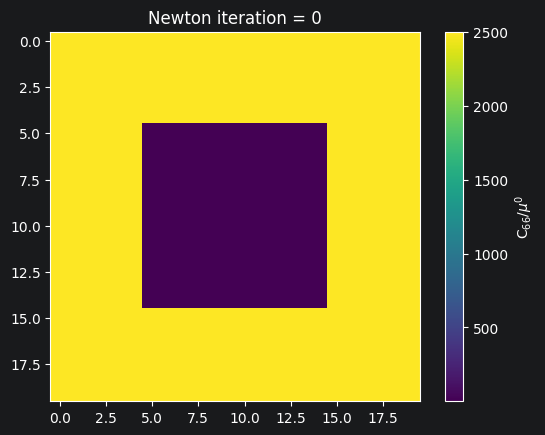

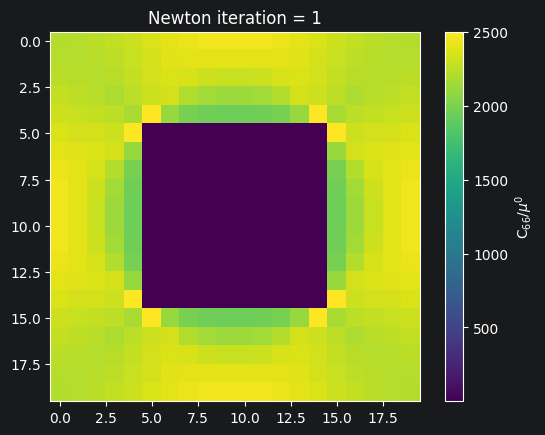

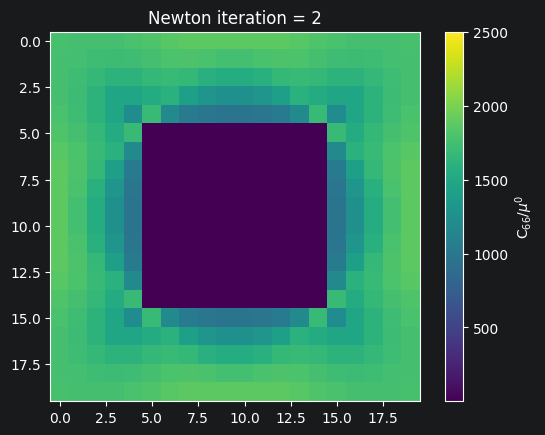

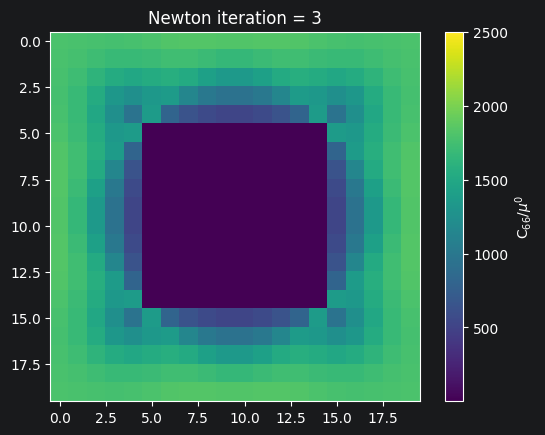

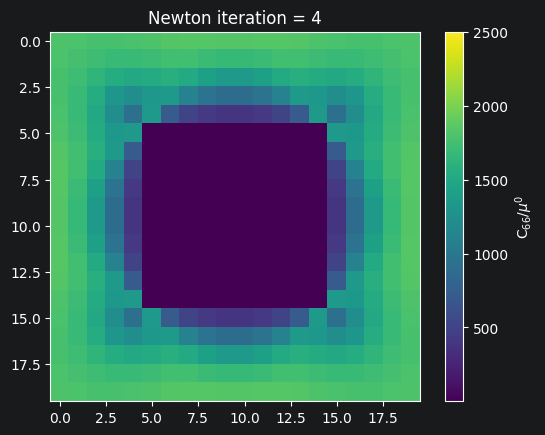

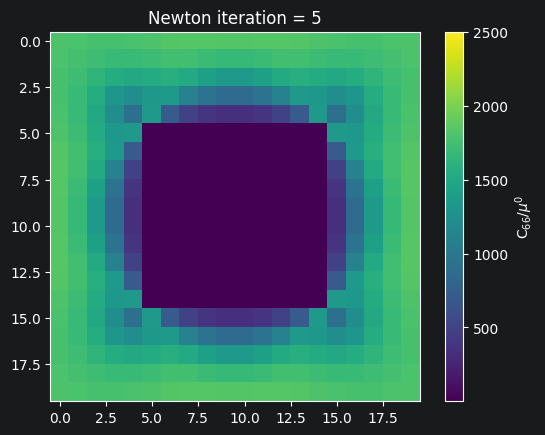

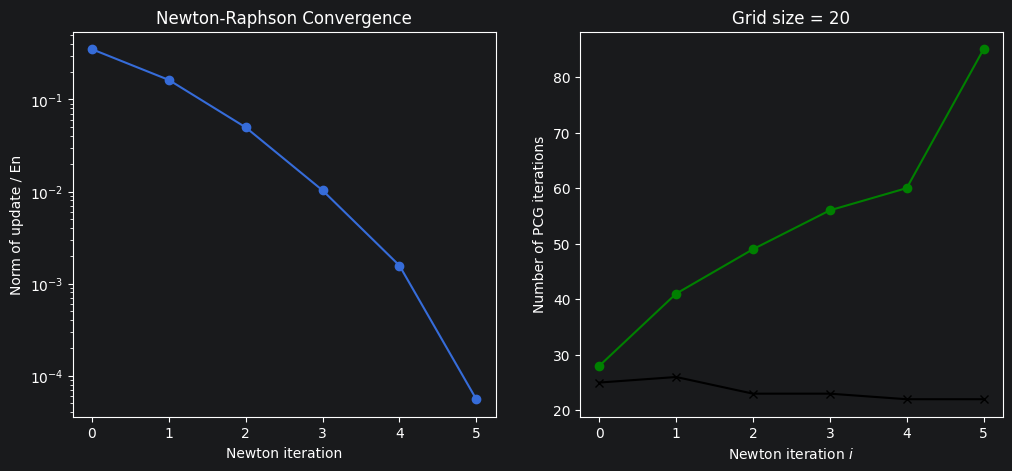

In [4]:
total_number_CG_per_grid_size_Green = []
total_number_CG_per_grid_size_GreenJacobi = []
nb_grid_points = [8,12,16,20]#[16,32,64]
for nb_points in nb_grid_points:  #,55,65,75
    # Problem Parameters
    # ------------------
    nb_quad_points_per_pixel = 8
    ndim = 3  # number of dimensions
    N_x = N_y = N_z = nb_points  # number of voxels
    N = (N_x, N_y, N_z)

    domain_size = (1, 1, 1)
    domain_vol = np.prod(domain_size)
    pixel_size = tuple(np.array(domain_size) / np.array(N))

    # Degrees of freedom configuration
    n_u_dofs = ndim  # displacement dofs per node
    ndof = n_u_dofs * np.prod(np.array(N))

    displacement_shape = (ndim,) + N
    grad_shape = (ndim, ndim, nb_quad_points_per_pixel) + N

    # Basic FFT operators and tensor dot products
    dot22 = lambda A2, B2: np.einsum('ij...,ij...->...', A2, B2)
    dot21 = lambda A, v: np.einsum('ij...,j...->i...', A, v)
    ddot42 = lambda A, B: np.einsum('ijkl...,lk...->ij...', A, B)
    dyad22 = lambda A2, B2: np.einsum('ij...,kl...->ijkl...', A2, B2)
    fft = lambda x: np.fft.fftn(x, [*N])
    ifft = lambda x: np.fft.ifftn(x, [*N])

    # Initialize gradient operators
    B, Bw_t, quadrature_weights = get_gradient_operators(pixel_size, N, n_u_dofs)

    # identity tensors for elasticity
    i = np.eye(ndim)
    I4 = np.einsum('il,jk', i, i)
    I4rt = np.einsum('ik,jl', i, i)
    I4s = (I4 + I4rt) / 2.
    II = np.einsum('ij,kl ', i, i)
    I = np.einsum('ij,qxyz...->ijqxyz...', i, np.ones((nb_quad_points_per_pixel,) + N))
    I4d = (I4s - II / 3.)

    # Stiffness parameters
    mu = 0.1  # shear modulus


    def elastic(eps):
        K = 2 * mu  # bulk  modulus
        # elastic stiffness tensor, and stress response
        C4 = K * II[..., np.newaxis, np.newaxis, np.newaxis, np.newaxis] + 2. * mu * I4d[
            ..., np.newaxis, np.newaxis, np.newaxis, np.newaxis]
        sig = ddot42(C4, eps)
        return sig, C4


    def nonlin_elastic(eps):
        K = 20 * mu  # bulk modulus
        sig0 = 5 * mu  # reference stress
        eps0 = 0.01  # reference strain
        n = 3.  # hardening exponent

        epsm = np.einsum('ii...', eps) / 3.  # trace / 3
        # epsm * I should broadcast correctly if I is (ndim, ndim, nb_quad, Nx, Ny, Nz)
        epsd = eps - epsm * I
        epseq = np.sqrt(2. / 3. * dot22(epsd, epsd))

        # avoid zero division
        mask = epseq > 1e-15
        epseq_safe = np.where(mask, epseq, 1.0)

        sig = 3. * K * epsm * I + (2. / 3. * sig0 / (eps0 ** n) * (epseq_safe ** (n - 1.)) * epsd)
        # mask is (nb_quad, Nx, Ny, Nz), sig is (ndim, ndim, nb_quad, Nx, Ny, Nz)
        mask_sig = mask[(np.newaxis,) * 2]
        sig = np.where(mask_sig, sig, 3. * K * epsm * I)

        K4_d = 2. / 3. * sig0 / (eps0 ** n) * (
                dyad22(epsd, epsd) * 2. / 3. * (n - 1.) * epseq_safe ** (n - 3.) + epseq_safe ** (n - 1.) * I4d[
            ..., np.newaxis, np.newaxis, np.newaxis, np.newaxis])
        # K4_d is (ndim, ndim, ndim, ndim, nb_quad, Nx, Ny, Nz)
        # mask is (nb_quad, Nx, Ny, Nz)
        # Ensure mask broadcasts to (ndim, ndim, ndim, ndim, nb_quad, Nx, Ny, Nz)
        mask_K4 = mask[(np.newaxis,) * 4]
        K4 = K * II[..., np.newaxis, np.newaxis, np.newaxis, np.newaxis] + np.where(mask_K4, K4_d, 0.0)

        return sig, K4


    # Reset phase field
    phase = np.zeros(N)
    phase[N_x // 4:3 * N_x // 4, N_y // 4:3 * N_y // 4, N_z // 4:3 * N_z // 4] = 1.


    def constitutive(eps):
        # phase is 1 for matrix, 0 for inclusion
        sig_P1, K4_P1 = nonlin_elastic(eps)
        sig_P2, K4_P2 = elastic(eps)

        # phase is (Nx, Ny, Nz), we need it for (..., Nx, Ny, Nz)
        # Adding np.newaxis at the beginning to help broadcasting
        p = phase[(np.newaxis,) * (len(eps.shape) - len(N))]

        sig = (1. - p) * sig_P1 + p * sig_P2

        p_K4 = phase[(np.newaxis,) * (len(K4_P1.shape) - len(N))]
        K4 = (1. - p_K4) * K4_P1 + p_K4 * K4_P2

        return sig, K4


    # Macroscopic loading
    macro_grad_ij = np.zeros([ndim, ndim])
    macro_grad_ij[0, 1] = 0.025
    macro_grad_ij[1, 0] = 0.025
    E_ijqxy = np.zeros(grad_shape)
    # Correct way to add macroscopic gradient to all points
    for i in range(ndim):
        for j in range(ndim):
            E_ijqxy[i, j, ...] = macro_grad_ij[i, j]

    # initialize: strain and stress/tangent
    eps = np.copy(E_ijqxy)
    sig, K4 = constitutive(eps)

    # Define system matrix operator K(u) and RHS vector b
    K_fun_I = lambda x: Bw_t(
        ddot42(K4,
               B(x.reshape(displacement_shape)))).reshape(-1)
    b_I = -Bw_t(sig).reshape(-1)

    # --- Newton-Raphson Loop ---
    En = np.linalg.norm(eps)
    iiter = 0
    norm_fluctuation = []
    nb_iter_CG_per_Newton_Green = []
    nb_iter_CG_per_Newton_GreenJacobi = []
    print(f"Starting Newton-Raphson iterations...")

    from IPython.display import clear_output

    # delete previous figure from the cell
    clear_output(wait=True)
    while True:

        # plot data
        norm = mpl.colors.Normalize(vmin=1, vmax=2500)

        fig, ax = plt.subplots()
        ax.set_title('Newton iteration = {}'.format(iiter))
        im = ax.imshow(K4[0, 1, 0, 1, ..., N_z // 2].mean(axis=0) / 0.1, cmap='viridis', norm=norm)
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(r'$\mathrm{C}_{66}/\mu^0$')
        plt.show()
        # --- Preconditioner (Green's) ---
        # Use a reference material for Green's preconditioner

        K_0 = 2 * mu
        mu_0 = mu
        ref_mat_data_ijkl = K_0 * II + 2. * mu_0 * (I4s - 1. / 3. * II)
        #ref_mat_data_ijkl = K4.mean(axis=(-1,-2,-3,-4)) # If you want to use the average K4 in current iteration
        ref_mat_data_ijkl_field = ref_mat_data_ijkl[..., np.newaxis, np.newaxis, np.newaxis, np.newaxis]

        # 1. Green's Preconditioner
        def get_green_preconditioner(ref_mat):
            K_ref_fun = lambda x: Bw_t(ddot42(ref_mat, B(x.reshape(displacement_shape))))
            G_diag_ijxy = np.zeros([n_u_dofs, n_u_dofs, *N])
            for d in range(n_u_dofs):
                unit_impuls_ixy = np.zeros(displacement_shape)
                unit_impuls_ixy[(d,) + ndim * (0,)] = 1
                G_diag_ijxy[:, d, ...] = K_ref_fun(x=unit_impuls_ixy)
            G_diag_ijxy = np.real(fft(x=G_diag_ijxy))
            reshaped_matrices = G_diag_ijxy.reshape(n_u_dofs, n_u_dofs, -1)
            G_batch = reshaped_matrices.transpose(2, 0, 1)
            G_batch[1:, ...] = np.linalg.inv(G_batch[1:, ...])
            M_diag_ijxy = G_batch.transpose(1, 2, 0).reshape(n_u_dofs, n_u_dofs, *N)
            return lambda x: np.real(ifft(dot21(M_diag_ijxy, fft(x=x.reshape(displacement_shape))))).reshape(-1)


        Green_fun_I = get_green_preconditioner(ref_mat_data_ijkl_field)


        # 2. Jacobi Preconditioner
        Jacobi_diag_ixy = np.zeros([n_u_dofs, *N])
        for d_i in range(ndim):
            for x_i in range(2):
                for y_i in range(2):
                    comb_impuls_ixy = np.zeros(displacement_shape)
                    comb_impuls_ixy[d_i, x_i::2, y_i::2] = 1.0
                    comb_impuls_ixy = K_fun_I(x=comb_impuls_ixy).reshape(displacement_shape)
                    Jacobi_diag_ixy[d_i, x_i::2, y_i::2] = np.where(
                        comb_impuls_ixy[d_i, x_i::2, y_i::2] != 0.,
                        1 / np.sqrt(comb_impuls_ixy[d_i, x_i::2, y_i::2]), 1.)

        Jacobi_fun = lambda x: Jacobi_diag_ixy * Jacobi_diag_ixy * x.reshape(displacement_shape)

        # 3. Green-Jacobi Preconditioner
        ref_mat_data_ijkl = I4s
        ref_mat_data_ijkl_field = ref_mat_data_ijkl[..., np.newaxis, np.newaxis, np.newaxis, np.newaxis]
        Green_fun_for_jacobi = get_green_preconditioner(ref_mat_data_ijkl_field)

        GreenJacobi_fun = lambda x: (Jacobi_diag_ixy * Green_fun_for_jacobi(Jacobi_diag_ixy * x.reshape(displacement_shape)).reshape(
            displacement_shape))
        # Update tangent operator based on current K4
        K_op = sp.LinearOperator((ndof, ndof),
                                 lambda x: Bw_t(ddot42(K4, B(x.reshape(displacement_shape)))).reshape(-1))

        # Solve linear system: K_tangent * deps = -RHS
        # Solver with Green Preconditioner
        nb_iter_CG = [0]


        def callback(x):
            nb_iter_CG[0] += 1

        dx_m, status = sp.cg(K_op, b_I, M=sp.LinearOperator((ndof, ndof), Green_fun_I),
                             rtol=1e-5, maxiter=10000, callback=callback
                             )
        nb_iter_CG_per_Newton_Green.append(nb_iter_CG)

        #print(f"Newton iter {iiter}: Green CG iters = {nb_iter_CG}")
        # Solver with Green-Jacobi Preconditioner
        nb_iter_CG = [0]
        def callback(x):
            nb_iter_CG[0] += 1

        dx_m, status = sp.cg(K_op, b_I, M=sp.LinearOperator((ndof, ndof), GreenJacobi_fun),
                             rtol=1e-5, maxiter=10000, callback=callback
                             )
        nb_iter_CG_per_Newton_GreenJacobi.append(nb_iter_CG)
        #print(f"Newton iter {iiter}: Green-Jacobi CG iters = {nb_iter_CG} ")
        depsm = B(dx_m.reshape(displacement_shape))
        eps += depsm.reshape(grad_shape)

        # Update stress and tangent
        sig, K4 = constitutive(eps)
        b_I = -Bw_t(sig).reshape(-1)

        res_norm = np.linalg.norm(depsm) / En
        norm_fluctuation.append(np.linalg.norm(depsm))
        #print(f"Newton iter {iiter}: Residual = {res_norm:.2e}")

        if res_norm < 1e-4 and iiter > 0:
            break
        if iiter > 50:
            print("Max Newton iterations reached")
            break
        iiter += 1

    total_number_CG_per_grid_size_Green.append(np.sum(nb_iter_CG_per_Newton_Green))
    total_number_CG_per_grid_size_GreenJacobi.append(np.sum(nb_iter_CG_per_Newton_GreenJacobi))

    # Plot results
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.semilogy(norm_fluctuation / En, 'o-')
    plt.xlabel('Newton iteration')
    plt.ylabel('Norm of update / En')
    plt.title('Newton-Raphson Convergence')

    plt.subplot(1, 2, 2)
    plt.plot(nb_iter_CG_per_Newton_Green, 'o-',color='Green')
    plt.plot(nb_iter_CG_per_Newton_GreenJacobi, 'x-',color='k')

    plt.xlabel(r'Newton iteration $i$')
    plt.ylabel('Number of PCG iterations')
    plt.title('Grid size = ' + str(nb_points) + '')
    plt.show()
    plt.close(fig)   # remove figure from memory + notebook output
    fig.clf()

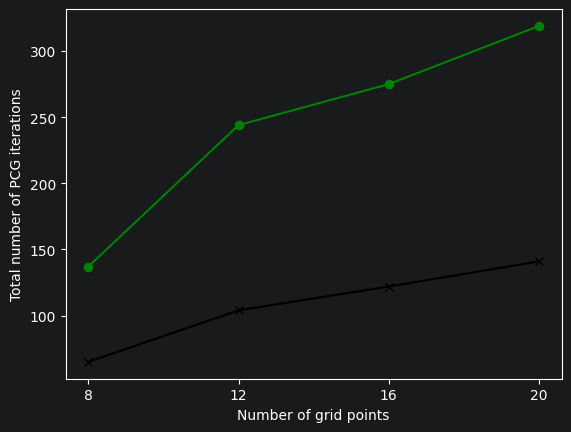

In [5]:
fig, ax = plt.subplots(1, 1)

ax.plot(total_number_CG_per_grid_size_Green, 'o-',color='Green')
ax.plot(total_number_CG_per_grid_size_GreenJacobi, 'x-',color='k')

ax.set_ylabel('Total number of PCG iterations')
ax.set_xlabel('Number of grid points')
ax.set_xticks(range(len(nb_grid_points)))
ax.set_xticklabels(nb_grid_points)
plt.show()